In [17]:
from flatland.envs.rail_env import RailEnv
from flatland.envs.rail_generators import sparse_rail_generator
from flatland.envs.line_generators import sparse_line_generator
from switchfl.switch_env import ASyncSwitchEnv

env_width = 18
env_height = 18

random_seed = 450565
rail_env = RailEnv(
    width=env_width,
    height=env_height,
    rail_generator=sparse_rail_generator(
        max_num_cities=5,
        grid_mode=True,
        max_rails_between_cities=1,
        max_rail_pairs_in_city=1,
        seed=random_seed,
    ),
    number_of_agents=2,
    )

obs = rail_env.reset(random_seed=random_seed)

a = rail_env.render()

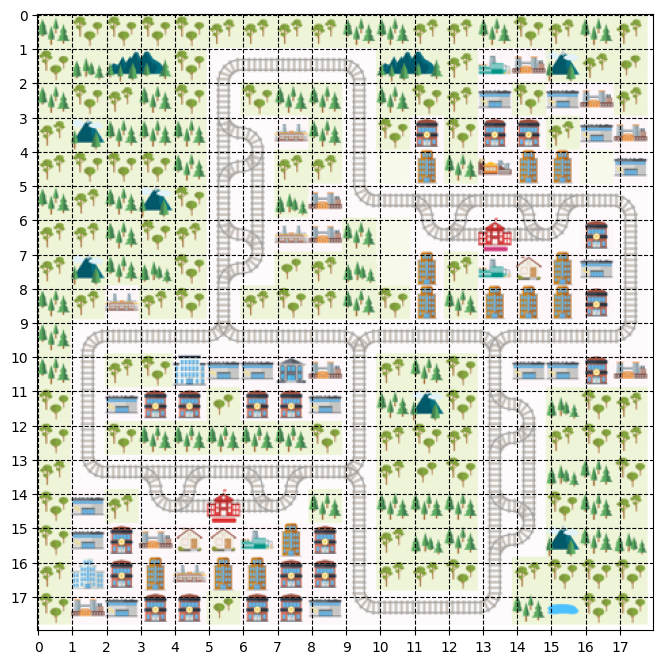

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))
plt.show()

In [19]:
from switchfl.utils.rail_graph import create_rail_graph

graph = create_rail_graph(rail_env)



100%|██████████| 1296/1296 [00:00<00:00, 80280.87it/s]


In [20]:
graph.nodes

NodeView(((1, 5), (1, 6), (2, 5), (1, 7), (1, 8), (1, 9), (2, 9), (3, 5), (3, 9), (3, 6), (4, 5), (4, 6), (4, 9), (5, 5), (5, 6), (5, 9), (6, 5), (6, 6), (5, 10), (5, 11), (5, 12), (6, 11), (5, 13), (6, 12), (5, 14), (5, 15), (6, 14), (5, 16), (6, 15), (5, 17), (6, 17), (7, 5), (7, 6), (6, 13), (7, 17), (8, 5), (8, 17), (9, 5), (9, 17), (9, 1), (9, 2), (10, 1), (9, 3), (9, 4), (9, 6), (9, 7), (9, 8), (9, 9), (9, 10), (10, 9), (9, 11), (9, 12), (9, 13), (9, 14), (10, 13), (9, 15), (9, 16), (11, 1), (11, 9), (11, 13), (12, 1), (12, 9), (11, 14), (12, 13), (12, 14), (13, 1), (13, 9), (13, 13), (13, 14), (13, 2), (13, 3), (13, 4), (14, 3), (13, 5), (14, 4), (13, 6), (13, 7), (14, 6), (13, 8), (14, 7), (14, 9), (14, 13), (14, 14), (14, 5), (15, 9), (15, 13), (15, 14), (16, 9), (16, 13), (17, 9), (17, 13), (17, 10), (17, 11), (17, 12)))

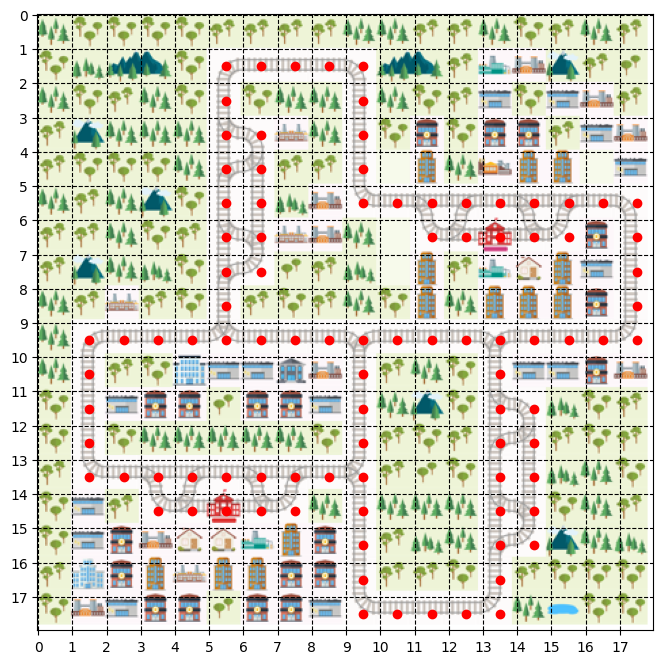

In [21]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))


for node in list(graph.nodes):
    x, y = node
    plt.plot(
        y*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        x*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        'ro'
    )

plt.show()

In [22]:
from switchfl.utils.rail_graph import insert_switch_proximity_nodes

graph = insert_switch_proximity_nodes(graph)

graph.nodes


NodeView(((1, 5), (1, 6), (2, 5), (1, 7), (1, 8), (1, 9), (2, 9), (3, 5), (3, 9), (3, 6), (4, 5), (4, 6), (4, 9), (5, 5), (5, 6), (5, 9), (6, 5), (6, 6), (5, 10), (5, 11), (5, 12), (6, 11), (5, 13), (6, 12), (5, 14), (5, 15), (6, 14), (5, 16), (6, 15), (5, 17), (6, 17), (7, 5), (7, 6), (6, 13), (7, 17), (8, 5), (8, 17), (9, 5), (9, 17), (9, 1), (9, 2), (10, 1), (9, 3), (9, 4), (9, 6), (9, 7), (9, 8), (9, 9), (9, 10), (10, 9), (9, 11), (9, 12), (9, 13), (9, 14), (10, 13), (9, 15), (9, 16), (11, 1), (11, 9), (11, 13), (12, 1), (12, 9), (11, 14), (12, 13), (12, 14), (13, 1), (13, 9), (13, 13), (13, 14), (13, 2), (13, 3), (13, 4), (14, 3), (13, 5), (14, 4), (13, 6), (13, 7), (14, 6), (13, 8), (14, 7), (14, 9), (14, 13), (14, 14), (14, 5), (15, 9), (15, 13), (15, 14), (16, 9), (16, 13), (17, 9), (17, 13), (17, 10), (17, 11), (17, 12), (3.2, 5.2), (3.1, 5.1), (3.4, 5.4), (4.1, 5.1), (4.4, 5.4), (4.2, 5.2), (4.2, 6.2), (4.4, 6.4), (4.3, 6.3), (6.2, 5.2), (6.1, 5.1), (6.4, 5.4), (6.2, 6.2), (6

In [23]:
graph.edges

EdgeView([((1, 5), (1, 6)), ((1, 5), (2, 5)), ((1, 6), (1, 7)), ((2, 5), (3.2, 5.2)), ((1, 7), (1, 8)), ((1, 8), (1, 9)), ((1, 9), (2, 9)), ((2, 9), (3, 9)), ((3, 5), (3.2, 5.2)), ((3, 5), (3.1, 5.1)), ((3, 5), (3.4, 5.4)), ((3, 9), (4, 9)), ((3, 6), (3.1, 5.1)), ((3, 6), (4.2, 6.2)), ((4, 5), (4.1, 5.1)), ((4, 5), (4.4, 5.4)), ((4, 5), (4.2, 5.2)), ((4, 6), (4.2, 6.2)), ((4, 6), (4.4, 6.4)), ((4, 6), (4.3, 6.3)), ((4, 9), (5, 9)), ((5, 5), (4.4, 5.4)), ((5, 5), (6.2, 5.2)), ((5, 6), (4.4, 6.4)), ((5, 6), (6.2, 6.2)), ((5, 9), (5, 10)), ((6, 5), (6.2, 5.2)), ((6, 5), (6.1, 5.1)), ((6, 5), (6.4, 5.4)), ((6, 6), (6.2, 6.2)), ((6, 6), (6.4, 6.4)), ((6, 6), (6.3, 6.3)), ((5, 10), (5.3, 11.3)), ((5, 11), (5.3, 11.3)), ((5, 11), (5.1, 11.1)), ((5, 11), (5.4, 11.4)), ((5, 12), (5.1, 12.1)), ((5, 12), (5.4, 12.4)), ((5, 12), (5.3, 12.3)), ((6, 11), (5.4, 11.4)), ((6, 11), (6.3, 12.3)), ((5, 13), (5.1, 12.1)), ((5, 13), (5.3, 14.3)), ((6, 12), (6.3, 12.3)), ((6, 12), (6.1, 12.1)), ((6, 12), (6.

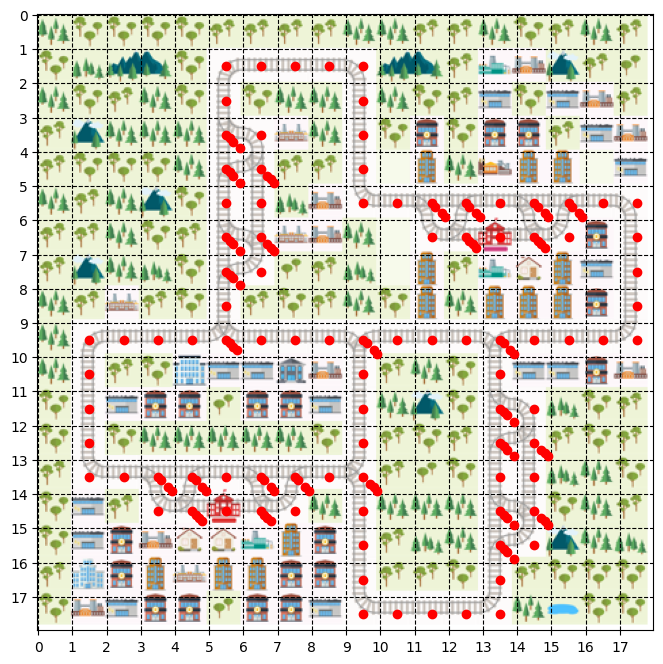

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))


for node in list(graph.nodes):
    x, y = node
    plt.plot(
        y*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        x*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        'ro'
    )

plt.show()

In [8]:
from switchfl.utils.rail_graph import prune_non_switches

graph = prune_non_switches(graph)

graph.nodes


NodeView(((3, 5), (4, 5), (4, 6), (6, 5), (6, 6), (5, 11), (5, 12), (6, 12), (5, 14), (5, 15), (6, 14), (7, 5), (9, 5), (9, 9), (9, 13), (11, 13), (12, 13), (12, 14), (13, 9), (13, 3), (13, 4), (14, 4), (13, 6), (13, 7), (14, 6), (14, 13), (14, 14), (15, 13), (3.2, 5.2), (3.1, 5.1), (3.4, 5.4), (4.1, 5.1), (4.4, 5.4), (4.2, 5.2), (4.2, 6.2), (4.4, 6.4), (4.3, 6.3), (6.2, 5.2), (6.1, 5.1), (6.4, 5.4), (6.2, 6.2), (6.4, 6.4), (6.3, 6.3), (5.3, 11.3), (5.1, 11.1), (5.4, 11.4), (5.1, 12.1), (5.4, 12.4), (5.3, 12.3), (6.3, 12.3), (6.1, 12.1), (6.2, 12.2), (5.3, 14.3), (5.1, 14.1), (5.4, 14.4), (5.1, 15.1), (5.4, 15.4), (5.3, 15.3), (6.3, 14.3), (6.1, 14.1), (6.2, 14.2), (7.1, 5.1), (7.4, 5.4), (7.2, 5.2), (9.2, 5.2), (9.3, 5.3), (9.1, 5.1), (9.3, 9.3), (9.1, 9.1), (9.4, 9.4), (9.3, 13.3), (9.1, 13.1), (9.4, 13.4), (11.2, 13.2), (11.1, 13.1), (11.4, 13.4), (12.1, 13.1), (12.4, 13.4), (12.2, 13.2), (12.2, 14.2), (12.4, 14.4), (12.3, 14.3), (13.2, 9.2), (13.3, 9.3), (13.4, 9.4), (13.3, 3.3), (

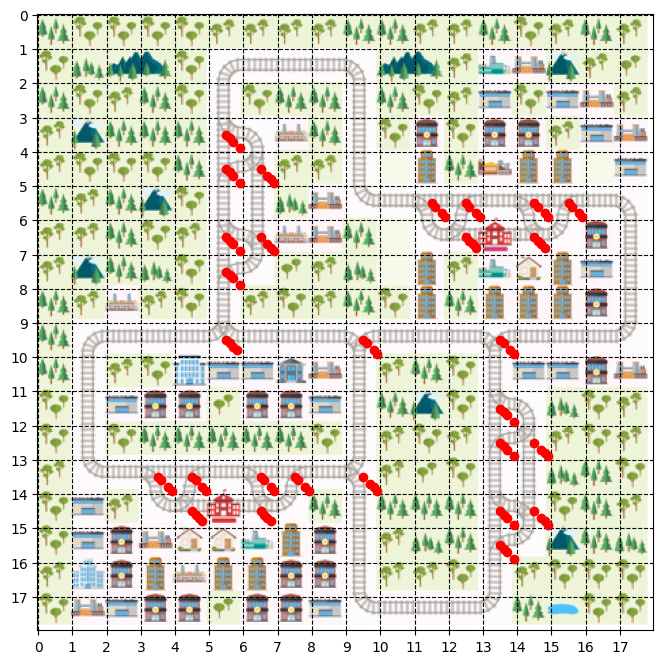

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))


for node in list(graph.nodes):
    x, y = node
    plt.plot(
        y*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        x*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        'ro'
    )

plt.show()

In [10]:
from switchfl.utils.rail_graph import generate_local_switch_graphs

graph = generate_local_switch_graphs(graph)

graph.nodes


NodeView(((3.2, 5.2), (3.1, 5.1), (3.4, 5.4), (4.1, 5.1), (4.4, 5.4), (4.2, 5.2), (4.2, 6.2), (4.4, 6.4), (4.3, 6.3), (6.2, 5.2), (6.1, 5.1), (6.4, 5.4), (6.2, 6.2), (6.4, 6.4), (6.3, 6.3), (5.3, 11.3), (5.1, 11.1), (5.4, 11.4), (5.1, 12.1), (5.4, 12.4), (5.3, 12.3), (6.3, 12.3), (6.1, 12.1), (6.2, 12.2), (5.3, 14.3), (5.1, 14.1), (5.4, 14.4), (5.1, 15.1), (5.4, 15.4), (5.3, 15.3), (6.3, 14.3), (6.1, 14.1), (6.2, 14.2), (7.1, 5.1), (7.4, 5.4), (7.2, 5.2), (9.2, 5.2), (9.3, 5.3), (9.1, 5.1), (9.3, 9.3), (9.1, 9.1), (9.4, 9.4), (9.3, 13.3), (9.1, 13.1), (9.4, 13.4), (11.2, 13.2), (11.1, 13.1), (11.4, 13.4), (12.1, 13.1), (12.4, 13.4), (12.2, 13.2), (12.2, 14.2), (12.4, 14.4), (12.3, 14.3), (13.2, 9.2), (13.3, 9.3), (13.4, 9.4), (13.3, 3.3), (13.1, 3.1), (13.4, 3.4), (13.1, 4.1), (13.4, 4.4), (13.3, 4.3), (14.3, 4.3), (14.1, 4.1), (14.2, 4.2), (13.3, 6.3), (13.1, 6.1), (13.4, 6.4), (13.1, 7.1), (13.4, 7.4), (13.3, 7.3), (14.3, 6.3), (14.1, 6.1), (14.2, 6.2), (14.2, 13.2), (14.1, 13.1), (1

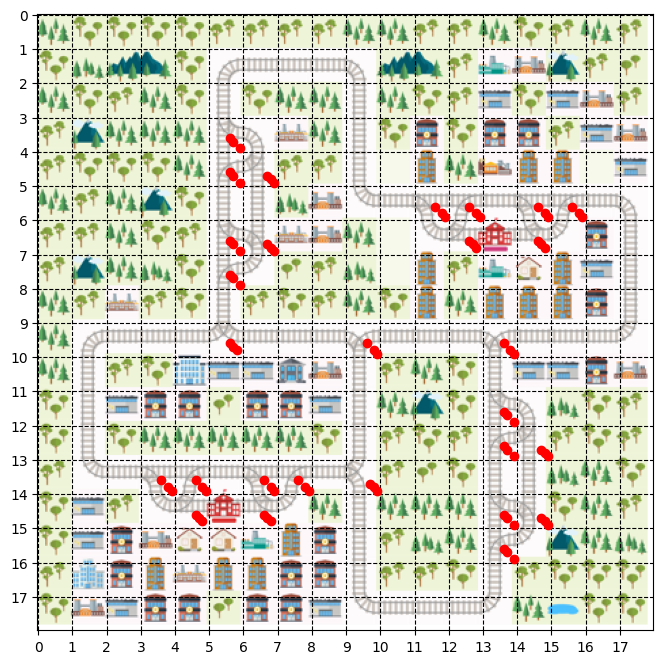

In [11]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))


for node in list(graph.nodes):
    x, y = node
    plt.plot(
        y*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        x*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        'ro'
    )

plt.show()

In [12]:
from switchfl.rail_network import build_switch_network

graph = build_switch_network(graph)

graph.nodes


NodeView(((3, 5), (4, 5), (4, 6), (5, 11), (5, 12), (5, 14), (5, 15), (6, 5), (6, 6), (6, 12), (6, 14), (7, 5), (9, 5), (9, 9), (9, 13), (11, 13), (12, 13), (12, 14), (13, 3), (13, 4), (13, 6), (13, 7), (13, 9), (14, 4), (14, 6), (14, 13), (14, 14), (15, 13)))

In [16]:
graph.edges

EdgeView([((3, 5), (4, 5)), ((3, 5), (4, 6)), ((3, 5), (5, 11)), ((4, 5), (4, 6)), ((4, 5), (6, 5)), ((4, 6), (6, 6)), ((5, 11), (5, 12)), ((5, 11), (6, 12)), ((5, 12), (5, 14)), ((5, 12), (6, 12)), ((5, 14), (5, 15)), ((5, 14), (6, 14)), ((5, 15), (6, 14)), ((5, 15), (9, 13)), ((6, 5), (7, 5)), ((6, 5), (6, 6)), ((6, 6), (7, 5)), ((6, 12), (6, 14)), ((7, 5), (9, 5)), ((9, 5), (13, 3)), ((9, 5), (9, 9)), ((9, 9), (9, 13)), ((9, 9), (13, 9)), ((9, 13), (11, 13)), ((11, 13), (12, 14)), ((11, 13), (12, 13)), ((12, 13), (12, 14)), ((12, 13), (14, 13)), ((12, 14), (14, 14)), ((13, 3), (13, 4)), ((13, 3), (14, 4)), ((13, 4), (13, 6)), ((13, 4), (14, 4)), ((13, 6), (13, 7)), ((13, 6), (14, 6)), ((13, 7), (14, 6)), ((13, 7), (13, 9)), ((13, 9), (15, 13)), ((14, 4), (14, 6)), ((14, 13), (14, 14)), ((14, 13), (15, 13)), ((14, 14), (15, 13))])

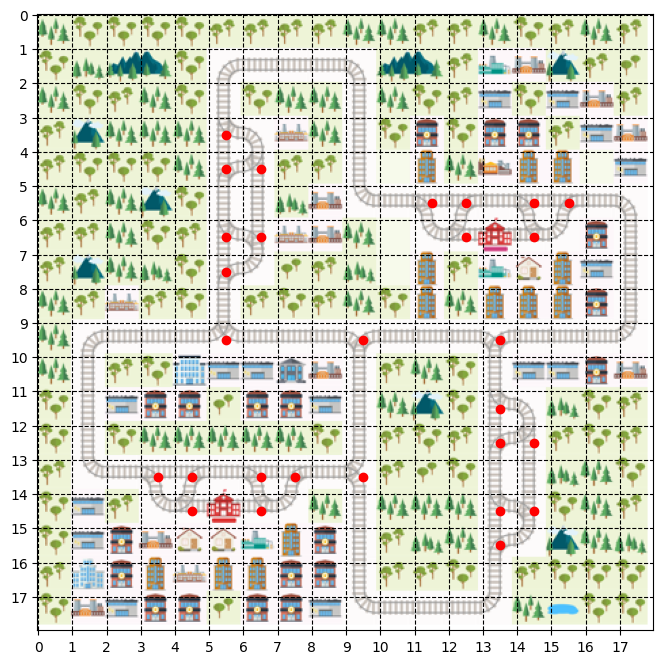

In [13]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))


for node in list(graph.nodes):
    x, y = node
    plt.plot(
        y*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        x*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        'ro'
    )

plt.show()

In [14]:
graph.edges

EdgeView([((3, 5), (4, 5)), ((3, 5), (4, 6)), ((3, 5), (5, 11)), ((4, 5), (4, 6)), ((4, 5), (6, 5)), ((4, 6), (6, 6)), ((5, 11), (5, 12)), ((5, 11), (6, 12)), ((5, 12), (5, 14)), ((5, 12), (6, 12)), ((5, 14), (5, 15)), ((5, 14), (6, 14)), ((5, 15), (6, 14)), ((5, 15), (9, 13)), ((6, 5), (7, 5)), ((6, 5), (6, 6)), ((6, 6), (7, 5)), ((6, 12), (6, 14)), ((7, 5), (9, 5)), ((9, 5), (13, 3)), ((9, 5), (9, 9)), ((9, 9), (9, 13)), ((9, 9), (13, 9)), ((9, 13), (11, 13)), ((11, 13), (12, 14)), ((11, 13), (12, 13)), ((12, 13), (12, 14)), ((12, 13), (14, 13)), ((12, 14), (14, 14)), ((13, 3), (13, 4)), ((13, 3), (14, 4)), ((13, 4), (13, 6)), ((13, 4), (14, 4)), ((13, 6), (13, 7)), ((13, 6), (14, 6)), ((13, 7), (14, 6)), ((13, 7), (13, 9)), ((13, 9), (15, 13)), ((14, 4), (14, 6)), ((14, 13), (14, 14)), ((14, 13), (15, 13)), ((14, 14), (15, 13))])

I nodi (3,5) e (4,6) non dovrebbero avere un edge secondo la modellazione di Giacomo perchè se dal (3,5) mando in (4,6) il treno, in (4,6) non c'è nessuna decisione che dev'essere presa (se il treno viene da quella direzione) quindi l'altro nodo sarà (6,5) invece

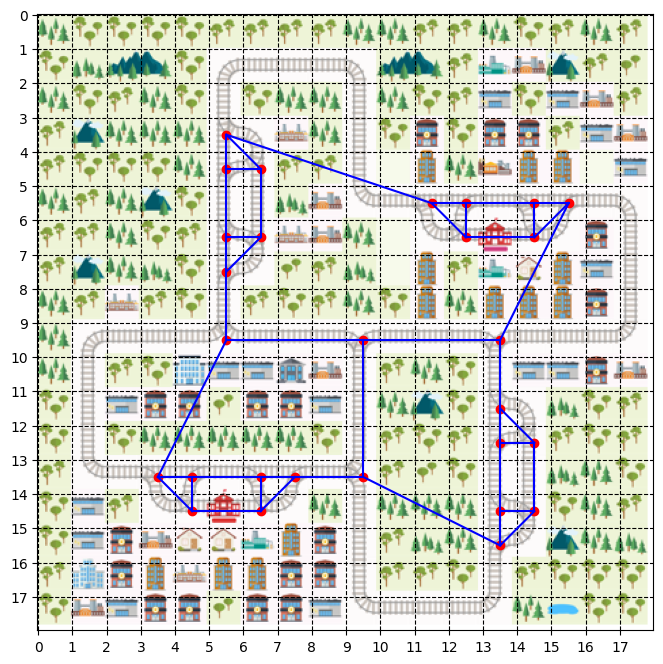

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(a)
ax.set_xticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.set_yticks(np.arange(0, a.shape[0], a.shape[0]/env_width), minor=False)
ax.xaxis.grid(True, which='major', color='black', linestyle='--')
ax.yaxis.grid(True, which='major', color='black', linestyle='--')
ax.set_xticklabels(np.arange(env_width))
ax.set_yticklabels(np.arange(env_height))


for node in list(graph.nodes):
    x, y = node
    plt.plot(
        y*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        x*a.shape[0]/(env_width) + a.shape[0]/(2*env_width),
        'ro'
    )

for edge in list(graph.edges):
    node1, node2 = edge
    x1, y1 = node1
    x2, y2 = node2
    plt.plot(
        [y1*a.shape[0]/(env_width) + a.shape[0]/(2*env_width), y2*a.shape[0]/(env_width) + a.shape[0]/(2*env_width)],
        [x1*a.shape[0]/(env_width) + a.shape[0]/(2*env_width), x2*a.shape[0]/(env_width) + a.shape[0]/(2*env_width)],
        'b-'
    )

plt.show()